In [1]:
# #Uncomment these in a fresh notebook environment.
# %cd /content/marl-tsc
# %pip install -r requirements.txt
# %pip install -e .

In [2]:
#GITHUB --> COLAB CLONE / env setup
import os

# Turn on libsumo for this specific script
os.environ["USE_LIBSUMO"] = "1"

from google.colab import userdata

# 1. Get your access token
token = userdata.get('GH_TOKEN')

# 2. Clone the repo if it's not already there
repo_path = '/content/marl-tsc'
if not os.path.exists(repo_path):
    !git clone --branch main --single-branch https://{token}@github.com/abergh18/marl-tsc.git

# 3. CRUCIAL: Move to the root directory
# This ensures that 'import models' or 'import utils' works correctly
%cd {repo_path}


# 4. Install dependencies
!pip install -r requirements.txt

Cloning into 'marl-tsc'...
remote: Enumerating objects: 1107, done.
remote: Counting objects: 100% (342/342), done.
remote: Compressing objects: 100% (178/178), done.
remote: Total 1107 (delta 240), reused 137 (delta 133), pack-reused 765 (from 1)
Receiving objects: 100% (1107/1107), 5.60 MiB | 14.59 MiB/s, done.
Resolving deltas: 100% (602/602), done.
/content/marl-tsc
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.5/805.5 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.2 MB/s

In [3]:
!pip install eclipse-sumo libsumo
# For simulation
!apt-get install -y xvfb
!pip install pyvirtualdisplay

import os
os.environ["SUMO_HOME"] = "/usr/local/lib/python3.12/dist-packages/sumo"
os.environ["PATH"] += ":/usr/local/lib/python3.12/dist-packages/sumo/bin"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.1/147.1 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.2/16.2 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.9/138.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.2/236.2 kB 20.1 MB/s eta 0:00:00
  Attempting uninstall: sumolib
    Found existing installation: sumolib 1.26.0
    Uninstalling sumolib-1.26.0:
      Successfully uninstalled sumolib-1.26.0
  Attempting uninstall: traci
    Found existing installation: traci 1.26.0
    Uninstalling traci-1.26.0:
      Successfully uninstalled traci-1.26.0
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [4]:
from pathlib import Path
import sys
#Had to remove '.parent' for colab specific version
PROJECT_ROOT = Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import traci
import sys

def print_comparison_table(rows):
  columns = [
        "Policy",
        "Episodes",
        "Mean total reward",
        "Mean local queue",
        "Mean max queue",
        "Mean waiting time",
        "Mean total time loss",
        "Total completed steps",
        "Mean switches / episode",
    ]

  def format_value(value):
        if isinstance(value, float):
            return f"{value:.3f}"
        return str(value)

  widths = {column: len(column) for column in columns}
  for row in rows:
      for column in columns:
          widths[column] = max(widths[column], len(format_value(row.get(column, ""))))

  header = " | ".join(column.ljust(widths[column]) for column in columns)
  separator = "-+-".join("-" * widths[column] for column in columns)
  print(header)
  print(separator)
  for row in rows:
      print(" | ".join(format_value(row.get(column, "")).ljust(widths[column]) for column in columns))

def reset_traci_connection():
    # Force clear TraCI's internal connection registries
    try:
        traci.switch("default")
        traci.close()
    except Exception:
        pass # No active connection to close

    try:
        # Completely purge the connection dictionary tracking connections
        if 'traci.main' in sys.modules:
            traci.main._connections.clear()
            print("Purged TraCI connections dictionary.")
    except Exception:
        pass

    # Reset the module completely out of Python sys memory
    if 'traci' in sys.modules:
        del sys.modules['traci']
        # Re-import fresh only if needed by subsequent code, otherwise it's handled by SumoTrafficEnv
    # print("TraCI state successfully reset!")

In [6]:
from marl_tsc.simulation_generator import SimulationGenerator
from marl_tsc.training import train_ppo, evaluate_policy, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions


NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / "outputs"


## 1. Generate the SUMO simulation files



In [7]:
import shutil
from pathlib import Path
import os
import sys
import site

site_packages = site.getsitepackages()[0]
sumo_path = Path(site_packages) / "sumo"

if not (sumo_path / "tools" / "randomTrips.py").exists():
    import sumo
    sumo_path = Path(sumo.__file__).parent

os.environ["SUMO_HOME"] = str(sumo_path)
os.environ["PATH"] += f":{sumo_path}/bin"
print(f"SUMO_HOME set to: {os.environ['SUMO_HOME']}")

# ==========================================
# MASTER VARIABLE: Controls the entire run
# ==========================================
EPISODE_STEPS = 1000
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION
TRAFFIC_SPAWN_DURATION = SIMULATION_DURATION
NUM_EPISODES = 30
EVALUATION_EPISODES = 5
TOTAL_TIMESTEPS = 300000
MIN_GREEN_SECONDS = 10

# ==========================================
# Network Configuration — change these to swap cities
# ==========================================
NETWORK_ONE_FILE = "lancasterv2.net.xml"
NETWORK_TWO_FILE = "york_cleaned.net.xml"

# ==========================================
# Output directories
# ==========================================
OUTPUT_DIR_ONE = PROJECT_ROOT / "outputs_network_one"
OUTPUT_DIR_TWO = PROJECT_ROOT / "outputs_network_two"
OUTPUT_DIR_ONE.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR_TWO.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = OUTPUT_DIR_ONE

vtypes_content = """<additional>
    <vType id="car"    vClass="passenger" speedFactor="normc(1,0.1,0.2,2)" length="4.5" maxSpeed="50"/>
    <vType id="van"    vClass="delivery"  speedFactor="normc(0.9,0.1,0.2,2)" length="6.0" maxSpeed="40"/>
    <vType id="bus"    vClass="bus"       speedFactor="normc(0.85,0.05,0.2,2)" length="12.0" maxSpeed="30"/>
</additional>"""

vtypes_one = OUTPUT_DIR_ONE / "vtypes.xml"
vtypes_one.write_text(vtypes_content)
vtypes_two = OUTPUT_DIR_TWO / "vtypes.xml"
vtypes_two.write_text(vtypes_content)

# ==========================================
# Network One
# ==========================================
net_one_path = OUTPUT_DIR_ONE / NETWORK_ONE_FILE
for p in [Path('/content') / NETWORK_ONE_FILE,
          Path('/content/marl-tsc') / NETWORK_ONE_FILE,
          net_one_path]:
    if p.exists():
        print(f"Found Network One at: {p}")
        if p.resolve() != net_one_path.resolve():
            shutil.copy2(p, net_one_path)
            print(f"Copied to {net_one_path}")
        break

generator_one = SimulationGenerator(
    output_dir=OUTPUT_DIR_ONE,
    network_filename=NETWORK_ONE_FILE,
    trip_fringe_factor=10,
    allow_fringe=True,
    trip_period=1,
    min_distance=50,
    vtypes_file=vtypes_one,
)
generator_one.generate_peak_trips(
    peak_end=int(SIMULATION_DURATION * 0.7)
)

generator_one.generate_config()
paths_one = generator_one.paths
tls_one = list(generator_one.traffic_light_ids)
print(f"Network One traffic lights ({len(tls_one)}): {tls_one}")

# ==========================================
# Network Two
# ==========================================
net_two_path = OUTPUT_DIR_TWO / NETWORK_TWO_FILE
for p in [Path('/content') / NETWORK_TWO_FILE,
          Path('/content/marl-tsc') / NETWORK_TWO_FILE,
          net_two_path]:
    if p.exists():
        print(f"Found Network Two at: {p}")
        if p.resolve() != net_two_path.resolve():
            shutil.copy2(p, net_two_path)
            print(f"Copied to {net_two_path}")
        break

generator_two = SimulationGenerator(
    output_dir=OUTPUT_DIR_TWO,
    network_filename=NETWORK_TWO_FILE,
    trip_fringe_factor=10,
    allow_fringe=True,
    trip_period=0.5,
    min_distance=50,
    vtypes_file=vtypes_two,
)
generator_two.generate_peak_trips(
    peak_end=int(SIMULATION_DURATION * 0.7)
)

generator_two.generate_config()
paths_two = generator_two.paths
tls_two = list(generator_two.traffic_light_ids)
print(f"Network Two traffic lights ({len(tls_two)}): {tls_two}")

# ==========================================
# Discover shared obs dimensions
# ==========================================
from marl_tsc.traffic_env import SumoTrafficEnv

reset_traci_connection()
env = SumoTrafficEnv(paths_one.config_file, possible_agents=tls_one, max_steps=10)
obs, _ = env.reset()
SHARED_MAX_LANES = env.max_lanes_per_tls
SHARED_GREEN_PHASES = env.green_phase_count
env.close()

reset_traci_connection()
env = SumoTrafficEnv(paths_two.config_file, possible_agents=tls_two, max_steps=10)
obs, _ = env.reset()
SHARED_MAX_LANES = max(SHARED_MAX_LANES, env.max_lanes_per_tls)
SHARED_GREEN_PHASES = max(SHARED_GREEN_PHASES, env.green_phase_count)
env.close()

print(f"Shared max_lanes_per_tls: {SHARED_MAX_LANES}")
print(f"Shared green_phase_count: {SHARED_GREEN_PHASES}")

TRAIN_ENV_KWARGS = {
    "min_green_seconds": MIN_GREEN_SECONDS,
    "max_lanes_per_tls": SHARED_MAX_LANES,
    "green_phase_count": SHARED_GREEN_PHASES,
}
EVAL_ENV_KWARGS = {
    "min_green_seconds": MIN_GREEN_SECONDS,
    "seconds_per_action": SECONDS_PER_ACTION,
    "switch_penalty": 0.0,
    "max_lanes_per_tls": SHARED_MAX_LANES,
    "green_phase_count": SHARED_GREEN_PHASES,
}

paths = paths_one
tls_in_net = tls_one

SUMO_HOME set to: /usr/local/lib/python3.12/dist-packages/sumo
Found Network One at: /content/marl-tsc/lancasterv2.net.xml
Copied to /content/marl-tsc/outputs_network_one/lancasterv2.net.xml
Discovered 8 traffic lights: ['cluster_1395459938_3904465077_6288784963', 'joinedS_6528610881_cluster_1305014216_5464547754_6100910_6528610880_cluster_2217469_5464547745_5464547748_5464547749', 'joinedS_cluster_1670999797_1670999973_2217366_3903086088_#1more_cluster_1670999799_2217365_6308327', 'joinedS_3903073405_cluster_5835265011_610595547', 'cluster_1671362532_2217405_253943174_3904937313_#3more', 'cluster_1111602959_6308330_6398665769_6398666101', 'cluster_2217373_5464742560_610595545_6288784968_#6more', 'cluster_27212021_5464547758_6299153326']
Network One traffic lights (8): ['cluster_1395459938_3904465077_6288784963', 'joinedS_6528610881_cluster_1305014216_5464547754_6100910_6528610880_cluster_2217469_5464547745_5464547748_5464547749', 'joinedS_cluster_1670999797_1670999973_2217366_39030860

In [8]:
import xml.etree.ElementTree as ET

for name, path in [("Network One", OUTPUT_DIR_ONE), ("Network Two", OUTPUT_DIR_TWO)]:
    tree = ET.parse(str(path / "routes.rou.xml"))
    root = tree.getroot()
    vehicles = root.findall("vehicle")
    if vehicles:
        departs = [float(v.get("depart", 0)) for v in vehicles]
        print(f"{name}: {len(vehicles)} vehicles | depart range: {min(departs):.0f}s - {max(departs):.0f}s | avg gap: {(max(departs)-min(departs))/len(vehicles):.2f}s")

Network One: 1750 vehicles | depart range: 1s - 1748s | avg gap: 1.00s
Network Two: 3500 vehicles | depart range: 0s - 1748s | avg gap: 0.50s


## 2. Run the simple baselines

Random and fixed-time are useful sanity checks before training. They use the same environment and the same evaluation seeds as the learned policies.


In [10]:
import traci
import sys

# ==========================================
# Network One Baselines
# ==========================================
reset_traci_connection()
random_one_result = evaluate_policy(
    config_file=paths_one.config_file,
    traffic_light_ids=tls_one,
    policy=random_actions,
    episodes=1,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs=EVAL_ENV_KWARGS,
)

reset_traci_connection()
fixed_one_result = evaluate_policy(
    config_file=paths_one.config_file,
    traffic_light_ids=tls_one,
    policy=fixed_time_actions,
    episodes=1,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs=EVAL_ENV_KWARGS,
)

# ==========================================
# Network Two Baselines
# ==========================================
reset_traci_connection()
random_two_result = evaluate_policy(
    config_file=paths_two.config_file,
    traffic_light_ids=tls_two,
    policy=random_actions,
    episodes=1,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs=EVAL_ENV_KWARGS,
)

reset_traci_connection()
fixed_two_result = evaluate_policy(
    config_file=paths_two.config_file,
    traffic_light_ids=tls_two,
    policy=fixed_time_actions,
    episodes=1,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs=EVAL_ENV_KWARGS,
)

print("Baselines complete.")

Finished Evaluation Episode 1/1 - Total Reward: -18163.74
Finished Evaluation Episode 1/1 - Total Reward: -33359.19
Finished Evaluation Episode 1/1 - Total Reward: -873.00
Finished Evaluation Episode 1/1 - Total Reward: -6520.45
Baselines complete.


## 3. Train

 MAPPO adds a centralized critic and a shared decentralized actor.


### MAPPO

[MAPPO] Episode 1 | Return: -1365.20 | Total Steps: 500
[MAPPO] Episode 2 | Return: -1318.64 | Total Steps: 1000
[MAPPO] Episode 3 | Return: -1303.83 | Total Steps: 1500
[MAPPO] Episode 4 | Return: -679.89 | Total Steps: 2000
[MAPPO] Episode 5 | Return: -1281.08 | Total Steps: 2500
[MAPPO] Episode 6 | Return: -1424.71 | Total Steps: 3000
[MAPPO] Episode 7 | Return: -1336.07 | Total Steps: 3500
[MAPPO] Episode 8 | Return: -1333.24 | Total Steps: 4000
[MAPPO] Episode 9 | Return: -1426.05 | Total Steps: 4500
[MAPPO] Episode 10 | Return: -1212.42 | Total Steps: 5000
[MAPPO] Episode 11 | Return: -1384.01 | Total Steps: 5500
[MAPPO] Episode 12 | Return: -1265.42 | Total Steps: 6000
[MAPPO] Episode 13 | Return: -1378.74 | Total Steps: 6500
[MAPPO] Episode 14 | Return: -1300.73 | Total Steps: 7000
[MAPPO] Episode 15 | Return: -1360.12 | Total Steps: 7500
[MAPPO] Episode 16 | Return: -1300.11 | Total Steps: 8000
[MAPPO] Episode 17 | Return: -1253.20 | Total Steps: 8500
[MAPPO] Episode 18 | Retu

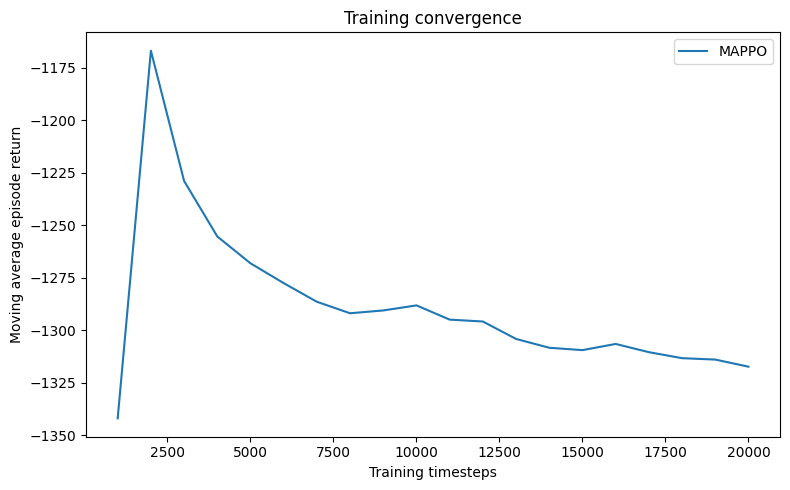

Saved MAPPO model: /content/marl-tsc/outputs_network_one/models/mappo.pt


In [11]:
reset_traci_connection()
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths_one.config_file,
    traffic_light_ids=tls_one,
    output_dir=OUTPUT_DIR_ONE,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=1000,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs=TRAIN_ENV_KWARGS,
    use_peer_reward=False,
)

fig, ax = plot_training_histories(mappo_history)
plt.show()
print("Saved MAPPO model:", mappo_model_path)

[MAPPO] Episode 1 | Return: -1049.71 | Total Steps: 500
[MAPPO] Episode 2 | Return: -1134.66 | Total Steps: 1000
[MAPPO] Episode 3 | Return: -1151.89 | Total Steps: 1500
[MAPPO] Episode 4 | Return: -1165.85 | Total Steps: 2000
[MAPPO] Episode 5 | Return: -1085.78 | Total Steps: 2500
[MAPPO] Episode 6 | Return: -972.17 | Total Steps: 3000
[MAPPO] Episode 7 | Return: -1203.88 | Total Steps: 3500
[MAPPO] Episode 8 | Return: -1058.04 | Total Steps: 4000
[MAPPO] Episode 9 | Return: -1188.11 | Total Steps: 4500
[MAPPO] Episode 10 | Return: -1123.30 | Total Steps: 5000
[MAPPO] Episode 11 | Return: -982.75 | Total Steps: 5500
[MAPPO] Episode 12 | Return: -1108.99 | Total Steps: 6000
[MAPPO] Episode 13 | Return: -1014.80 | Total Steps: 6500
[MAPPO] Episode 14 | Return: -1129.87 | Total Steps: 7000
[MAPPO] Episode 15 | Return: -1008.95 | Total Steps: 7500
[MAPPO] Episode 16 | Return: -1117.19 | Total Steps: 8000
[MAPPO] Episode 17 | Return: -1100.47 | Total Steps: 8500
[MAPPO] Episode 18 | Retur

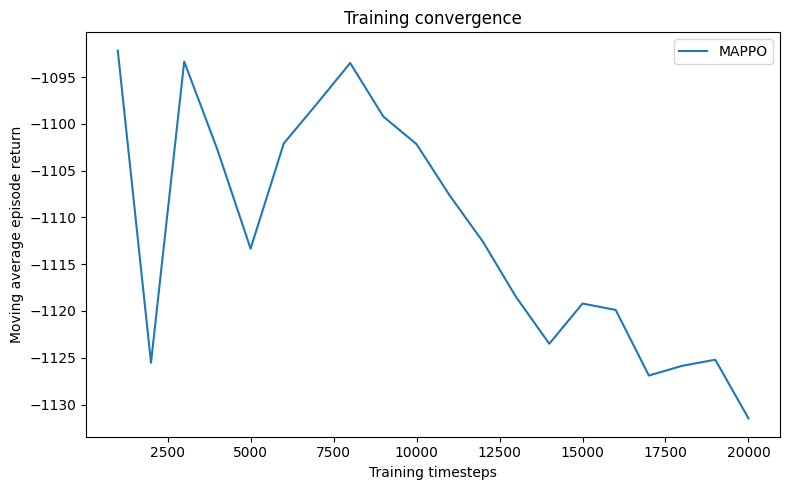

Saved Gifting MAPPO model: /content/marl-tsc/outputs_network_one/models/mappo_peer_reward.pt


In [12]:
reset_traci_connection()
gifting_mappo_model, gifting_mappo_history, gifting_mappo_model_path = train_mappo(
    config_file=paths_one.config_file,
    traffic_light_ids=tls_one,
    output_dir=OUTPUT_DIR_ONE,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=1000,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs=TRAIN_ENV_KWARGS,
    use_peer_reward=True,
)

fig, ax = plot_training_histories(gifting_mappo_history)
plt.show()
print("Saved Gifting MAPPO model:", gifting_mappo_model_path)

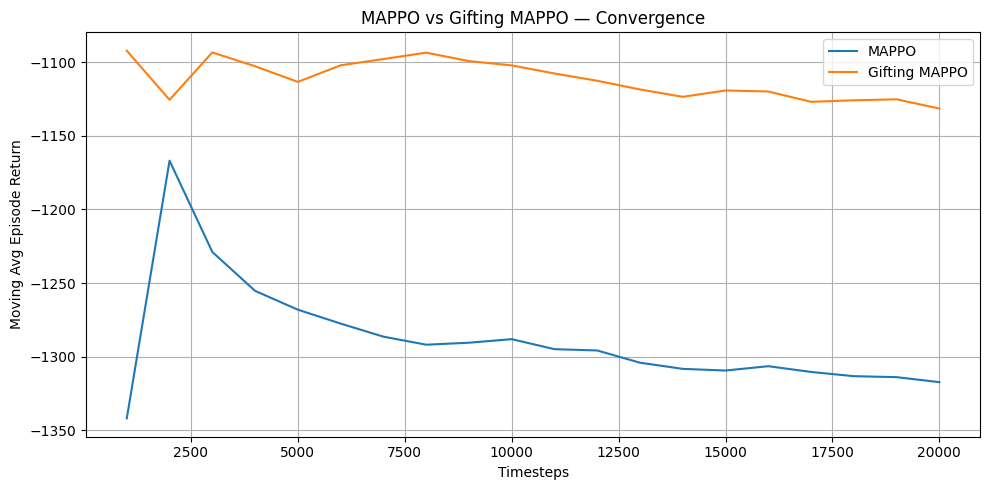

In [13]:
plt.close("all")

fig, ax = plt.subplots(figsize=(10, 5))

for label, history in [("MAPPO", mappo_history), ("Gifting MAPPO", gifting_mappo_history)]:
    if not history:
        continue
    timesteps = [h["timestep"] for h in history]
    returns = [h["moving_avg_episode_return"] for h in history]
    ax.plot(timesteps, returns, label=label)

ax.set_xlabel("Timesteps")
ax.set_ylabel("Moving Avg Episode Return")
ax.set_title("MAPPO vs Gifting MAPPO — Convergence")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 4. Evaluate all policies on the same seeds

The final comparison table keeps the baseline runs and adds the MAPPO policies on the same evaluation seeds.


In [14]:
# ==========================================
# Network One Evaluation (training network)
# ==========================================
reset_traci_connection()
mappo_one_result = evaluate_policy(
    config_file=paths_one.config_file,
    traffic_light_ids=tls_one,
    policy=mappo_model,
    episodes=EVALUATION_EPISODES,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs=EVAL_ENV_KWARGS,
)

reset_traci_connection()
gifting_mappo_one_result = evaluate_policy(
    config_file=paths_one.config_file,
    traffic_light_ids=tls_one,
    policy=gifting_mappo_model,
    episodes=EVALUATION_EPISODES,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs=EVAL_ENV_KWARGS,
)


# ==========================================
# Network Two Evaluation
# ==========================================
reset_traci_connection()
mappo_two_result = evaluate_policy(
    config_file=paths_two.config_file,
    traffic_light_ids=tls_two,
    policy=mappo_model,
    episodes=EVALUATION_EPISODES,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs=EVAL_ENV_KWARGS,
)

reset_traci_connection()
gifting_mappo_two_result = evaluate_policy(
    config_file=paths_two.config_file,
    traffic_light_ids=tls_two,
    policy=gifting_mappo_model,
    episodes=EVALUATION_EPISODES,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs=EVAL_ENV_KWARGS,
)

Finished Evaluation Episode 1/5 - Total Reward: -24788.61
Finished Evaluation Episode 2/5 - Total Reward: -27107.56
Finished Evaluation Episode 3/5 - Total Reward: -30683.37
Finished Evaluation Episode 4/5 - Total Reward: -27782.62
Finished Evaluation Episode 5/5 - Total Reward: -25172.30
Finished Evaluation Episode 1/5 - Total Reward: -24788.61
Finished Evaluation Episode 2/5 - Total Reward: -27107.56
Finished Evaluation Episode 3/5 - Total Reward: -30683.37
Finished Evaluation Episode 4/5 - Total Reward: -27782.62
Finished Evaluation Episode 5/5 - Total Reward: -25172.30
Finished Evaluation Episode 1/5 - Total Reward: -764.62
Finished Evaluation Episode 2/5 - Total Reward: -833.35
Finished Evaluation Episode 3/5 - Total Reward: -760.47
Finished Evaluation Episode 4/5 - Total Reward: -818.80
Finished Evaluation Episode 5/5 - Total Reward: -724.23
Finished Evaluation Episode 1/5 - Total Reward: -764.62
Finished Evaluation Episode 2/5 - Total Reward: -833.35
Finished Evaluation Episode 

In [15]:
def make_row(label, result):
    return {
        "Policy": label,
        "Episodes": result["episodes"],
        "Mean total reward": result["mean_total_reward"],
        "Reward per step": round(result["mean_total_reward"] / result["total_completed_steps"], 4),
        "Mean local queue": result["mean_local_queue"],
        "Mean max queue": result["mean_max_queue"],
        "Mean waiting time": result["mean_waiting_time"],
        "Mean total time loss": result["mean_total_time_loss"],
        "Time loss per vehicle": round(result["mean_total_time_loss"] / max(result["mean_vehicle_count"], 1), 2),
        "Arrived vehicles": result["mean_arrived_vehicles_per_episode"],
        "Total completed steps": result["total_completed_steps"],
        "Mean switches / episode": result["mean_switches_per_episode"],
    }

print("\n=== Network One Results (Training Network) ===")
print_comparison_table([
    make_row("Random", random_one_result),
    make_row("Fixed-Time", fixed_one_result),
    make_row("MAPPO", mappo_one_result),
    make_row("Gifting MAPPO", gifting_mappo_one_result),
])

print("\n=== Network Two Results (Zero-Shot Transfer) ===")
print_comparison_table([
    make_row("Random", random_two_result),
    make_row("Fixed-Time", fixed_two_result),
    make_row("MAPPO", mappo_two_result),
    make_row("Gifting MAPPO", gifting_mappo_two_result),
])


=== Network One Results (Training Network) ===
Policy        | Episodes | Mean total reward | Mean local queue | Mean max queue | Mean waiting time | Mean total time loss | Total completed steps | Mean switches / episode
--------------+----------+-------------------+------------------+----------------+-------------------+----------------------+-----------------------+------------------------
Random        | 1        | -18163.745        | 3.071            | 23.000         | 102.458           | 311774.733           | 500                   | 282.000                
Fixed-Time    | 1        | -33359.188        | 4.930            | 23.000         | 107.039           | 403360.541           | 500                   | 252.000                
MAPPO         | 5        | -27106.891        | 4.102            | 23.000         | 108.710           | 396832.468           | 2500                  | 269.400                
Gifting MAPPO | 5        | -27106.891        | 4.102            | 23.000         |

In [16]:
import subprocess

def clean_up_sumo_processes():
    """Forcefully terminate any stuck SUMO or TraCI background processes."""
    subprocess.run(["pkill", "-9", "sumo"], capture_output=True)
    subprocess.run(["pkill", "-9", "sumo-gui"], capture_output=True)


clean_up_sumo_processes()

In [17]:
import subprocess
from pathlib import Path

def save_sumo_trace(
    config_file,
    traffic_light_ids,
    policy,
    output_dir,
    max_steps=600,
    seed=42,
    filename="simulation_trace.xml",
):
    from marl_tsc.traffic_env import SumoTrafficEnv
    from marl_tsc.wrappers import MinimumGreenTimeWrapper, PeerRewardingWrapper

    output_dir = Path(output_dir)
    trace_path = output_dir / filename

    env = None
    try:
        # 1. Automatically grab the exact settings the model was trained with
        model_kwargs = getattr(policy, "config", {}).get("env_kwargs", {})

        # 2. Create the environment using those identical settings
        env = SumoTrafficEnv(
            config_file,
            possible_agents=traffic_light_ids,
            max_steps=max_steps,
            seed=seed,
            render_mode=None,
            **model_kwargs,
        )

        # 3. Apply the exact same wrappers we used for evaluation
        env = MinimumGreenTimeWrapper(env, min_green_steps=10)

        if hasattr(policy, "action_dims") and len(policy.action_dims) > 1:
            env = PeerRewardingWrapper(env, division=10)

        observations, infos = env.reset(seed=seed)

        for step in range(max_steps):
            # 4. Ask the policy for its action
            actions = policy.act(observations, infos=infos, deterministic=True)
            observations, rewards, _, truncations, infos = env.step(actions)

            # PettingZoo standard for checking if the episode is finished
            if all(truncations.values()):
                break

    finally:
        if env is not None:
            env.close()

    print(f"Trace saved to: {trace_path}")
    return trace_path

In [18]:
reset_traci_connection()

save_sumo_trace(
    config_file=paths.config_file,
    traffic_light_ids=tls_in_net,
    policy=mappo_model,
    output_dir=OUTPUT_DIR,
    max_steps=600,
    seed=42,
)

Trace saved to: /content/marl-tsc/outputs_network_one/simulation_trace.xml


PosixPath('/content/marl-tsc/outputs_network_one/simulation_trace.xml')

### Traci Escape Hatch

In [19]:
on = True
if on:
    # Stop Traci processes if not already stopped, to prevent connection issues in subsequent runs
    import sys

    # 1. Force clear TraCI's internal connection registries
    try:
        import traci
        traci.switch("default")
        traci.close()
    except Exception:
        pass

    try:
        # Completely purge the connection dictionary tracking connections
        import traci.main
        traci.main._connections.clear()
        print("Purged TraCI connections dictionary.")
    except Exception:
        pass

    # 2. Reset the module completely out of Python sys memory
    if 'traci' in sys.modules:
        del sys.modules['traci']
        print("Flushed TraCI module from Python runtime memory.")

    # 3. Re-import fresh
    import traci
    print("TraCI state successfully reset!")

Flushed TraCI module from Python runtime memory.
TraCI state successfully reset!


In [20]:
# Auto disconnects when run has done
from google.colab import runtime
runtime.unassign()